## Concordance between ClinVec embedding similarity and clinical expert scores


The `data/clinician_pair_scores.csv` contains all of the labeled clinical terms and pre-computed cosine similarity between ClinVec embeddings:

* 'phecode' - Phecode id corresponding to 1st term
* 'target_disease' - name of 1st clinical term
* 'node_name' - name of 2nd clinical term
* 'node_id' - SNOMED CT id corresponding to 2nd term
* 'score' - clinician graded score on scale 1 (least similar) to 5 (most similar)
* 'cos' - cosine similarity between phecode embedding and snomed ct embedding

In [4]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

all_df = pd.read_csv("clinician_pair_scores.csv")

Text(0, 0.5, 'Cosine similarity')

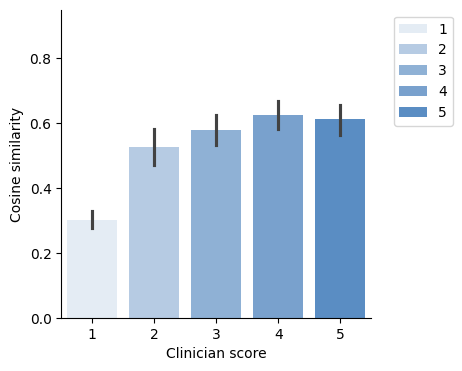

In [5]:
#
# Performance across all disease categories
#
plt.figure(figsize=(4, 4))

sns.barplot(data=all_df, x='score', y='cos',
            palette=['#e1ecf7', '#aecbeb','#83b0e1', '#6BA1DB', '#498CD4'], hue='score')
plt.ylim(0, 0.95)
sns.despine(top=True)

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.xlabel("Clinician score")
plt.ylabel("Cosine similarity")

Text(0, 0.5, 'Cosine similarity')

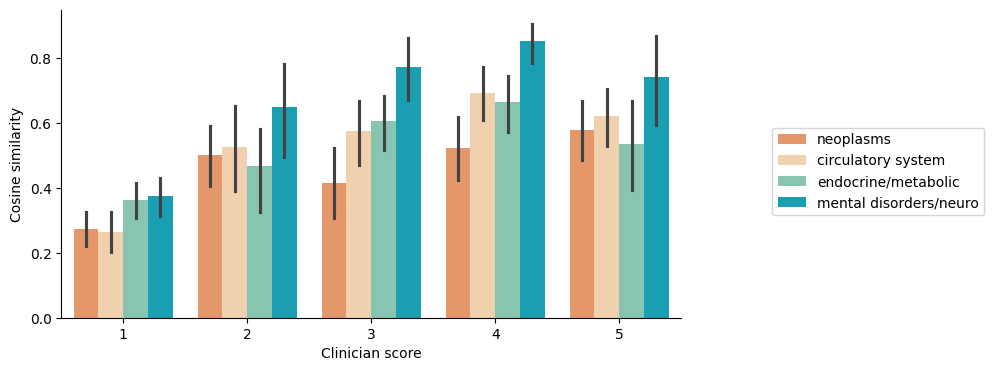

In [6]:
#
# Performance stratified by largest disease categories
#

plt.figure(figsize=(8, 4))
sns.barplot(data=all_df.loc[(all_df['category'].isin(['mental disorders/neuro', 'circulatory system', 'neoplasms', 'endocrine/metabolic'])) 
                            & (all_df['cos'] > -1)], x='score', y='cos',
            palette=['#f79256', '#fbd1a2','#7dcfb6', '#00b2ca'], hue='category',
            hue_order=['neoplasms', 'circulatory system', 'endocrine/metabolic', 'mental disorders/neuro'])
plt.ylim(0, 0.95)
sns.despine(top=True)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 0.64), ncol=1)
plt.xlabel("Clinician score")
plt.ylabel("Cosine similarity")